In [10]:
import warnings
warnings.filterwarnings("ignore")
import logging
# Suppress INFO logs, show only WARNING and above
logging.getLogger().setLevel(logging.WARNING)


from repspat import SampleData, spatial_silhouette_analysis,spatial_constrained_hac, plot_spatial_clusters, pairwise_results_to_matrix, multiple_comparison, create_blocks


In [2]:
data = SampleData(sample_column="sample_id", sample_name="Sample_04",adata_path='03_TNBC_2018_spe.h5ad')

In [3]:
data.summary()

{'feature_mat': (5381, 36),
 'coords_mat': (5381, 2),
 'dist_matrix': (5381, 5381),
 'cell_type': (5381, 1),
 'sample_adata': (5381, 36)}

In [4]:
spatial_silhouette_analysis(data, n_neighbors_list=[6,8], n_clusters_range=range(4,9))

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


,n_neighbors,n_clusters,avg_silhouette
0,6,4,0.136721
1,6,5,0.086261
2,6,6,0.092815
3,6,7,0.113284
4,6,8,0.127881
5,8,4,0.161823
6,8,5,0.137023
7,8,6,0.148935
8,8,7,0.159307
9,8,8,0.122112


In [4]:
labels, feature_df, model = spatial_constrained_hac(data.sample_adata, feature_df=data.feature_mat, n_clusters=7, n_neighs=8)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


In [6]:
x = data.coords_mat.centroidX
y = data.coords_mat.centroidY

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Spatial Plot of Cells with Cluster Colors'}, xlabel='X coordinate', ylabel='Y coordinate'>)

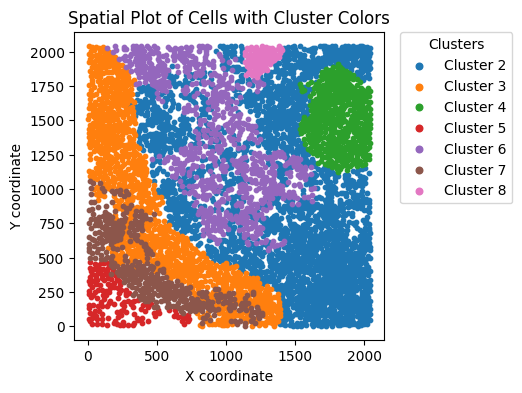

In [7]:
plot_spatial_clusters(x,y,labels=labels )

In [11]:
blocked_data = create_blocks(data.feature_mat, 36, 8)

In [12]:
results_df = multiple_comparison(blocked_data, data.dist_matrix, kernel='IMQ')

In [14]:
results_df[results_df['adj_p'] >= 0.05]

,region_1,region_2,obs_mmd_sq,p_value,null_dist,adj_p
12,2,3,0.007202,0.145,"[0.0030089423459331854, 0.009884180224305816, ...",0.152250
14,2,7,0.030408,0.065,"[0.03763043117408571, 0.014079895856199509, 0....",0.071842
19,3,7,0.014313,0.470,"[0.00770387825371055, 0.011692789056996333, 0....",0.470000


,1,4,2,5,3,6,7
1,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.000000,0.0,0.007202,0.0,0.030408
5,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.007202,0.0,0.000000,0.0,0.014313
6,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
7,0.0,0.0,0.030408,0.0,0.014313,0.0,0.000000


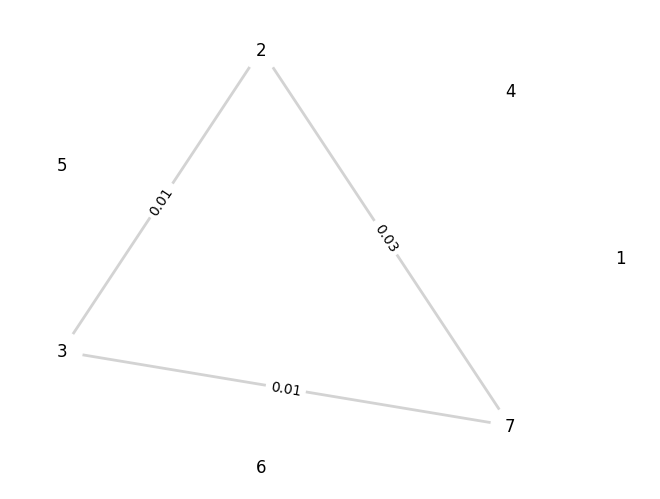

In [15]:
pairwise_results_to_matrix(results_df)